获取数据

               Close      High       Low      Open     Volume
Date                                                         
2021-01-04  4.762662  4.791234  4.696588  4.714446  506705639
2021-01-05  4.851058  4.861772  4.736768  4.751054  622830794
2021-01-06  4.894809  4.923382  4.836772  4.863558  374945107
2021-01-07  4.999277  5.000170  4.895702  4.901952  470659227
2021-01-08  4.974277  5.027850  4.927846  5.007313  697564767

数据范围: 2021-01-04 到 2026-08-14
数据总行数：1360


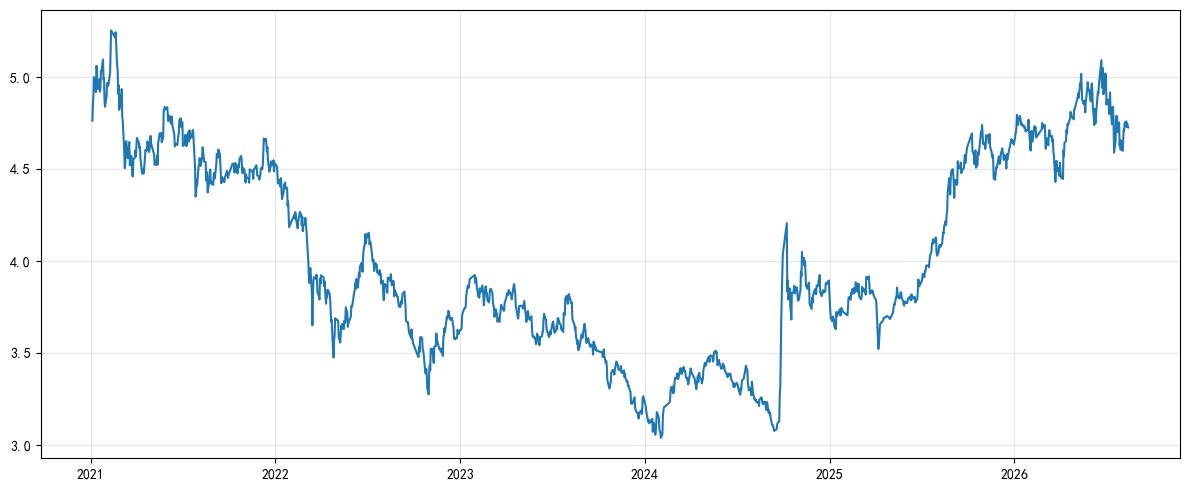

In [10]:
from multiprocessing import resource_sharer

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取数据
DATA_START = '2021-01-01'
DATA_END = '2026-08-14'
download_end = (pd.Timestamp(DATA_END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
df = yf.download('510300.SS', start=DATA_START, end=download_end, auto_adjust=True, multi_level_index=False, progress=False)
df = df.loc[:DATA_END]

print(df.head())
print(f"\n数据范围: {df.index[0].date()} 到 {df.index[-1].date()}")
print(f'数据总行数：{len(df)}')

# 画图
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

定投回测

In [12]:
def backtest_dca(df, mouthly_amount=1000):
    """
    定投回测
    """
    df = df.copy()
    df['month'] = df.index.to_period('M')

    # 每月第一个交易日买入
    mouthly_first = df.groupby('mouth').first()
    shares_bought = mouthly_amount / mouthly_first['Close']
    total_shares = shares_bought.cumsum()
    total_cost = mouthly_amount * np.arahge(1, len(mouthly_first) + 1)

    # 每月末市值
    mouthly_last = df.groupby('mouth').last()
    portfolio_value = total_shares * mouthly_last['Close']
    returns = (portfolio_value.valus - total_cost) / total_cost

    result_dca = pd.DataFrame({
        'total_cost': total_cost,
        'total_shares': total_shares,
        'portfolio_value': portfolio_value,
        'returns': returns
    }, index=mouthly_first.index)
    return result_dca

result_dca = backtest_dca(df)


KeyError: 'mouth'